# HOMEWORK 3

For this homework you are going to implement the **unsharp masking** filter (USM). It is a technique to improve the sharpness of an image by combining the image with its blurred (unsharp) version. See the Wikipedia [page](https://en.wikipedia.org/wiki/Unsharp_masking) for more details.

### Unsharp Masking (USP)
The USM technique consists of the following steps:
* Load the image you will be working with.
* Create a blurred (unsharp) version of the original image.
* Add the unsharp image (with a certain **weight**) to the original.

To sum it up, the USM performs the following operation:

`sharpened = original + (original − unsharp) × amount`

Even though we provide you an image to work with, you are welcome to use your own images :-)

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

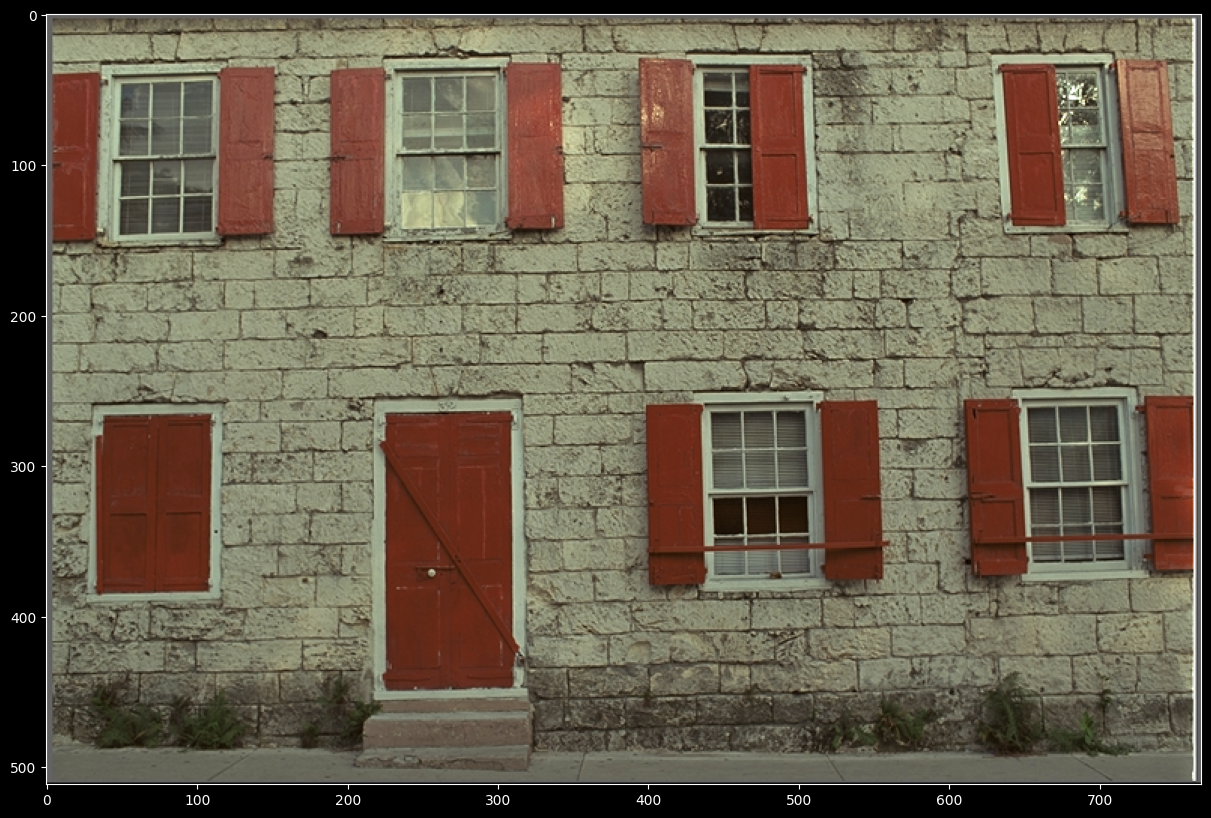

In [2]:
img = cv2.imread('../data/kodim01.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

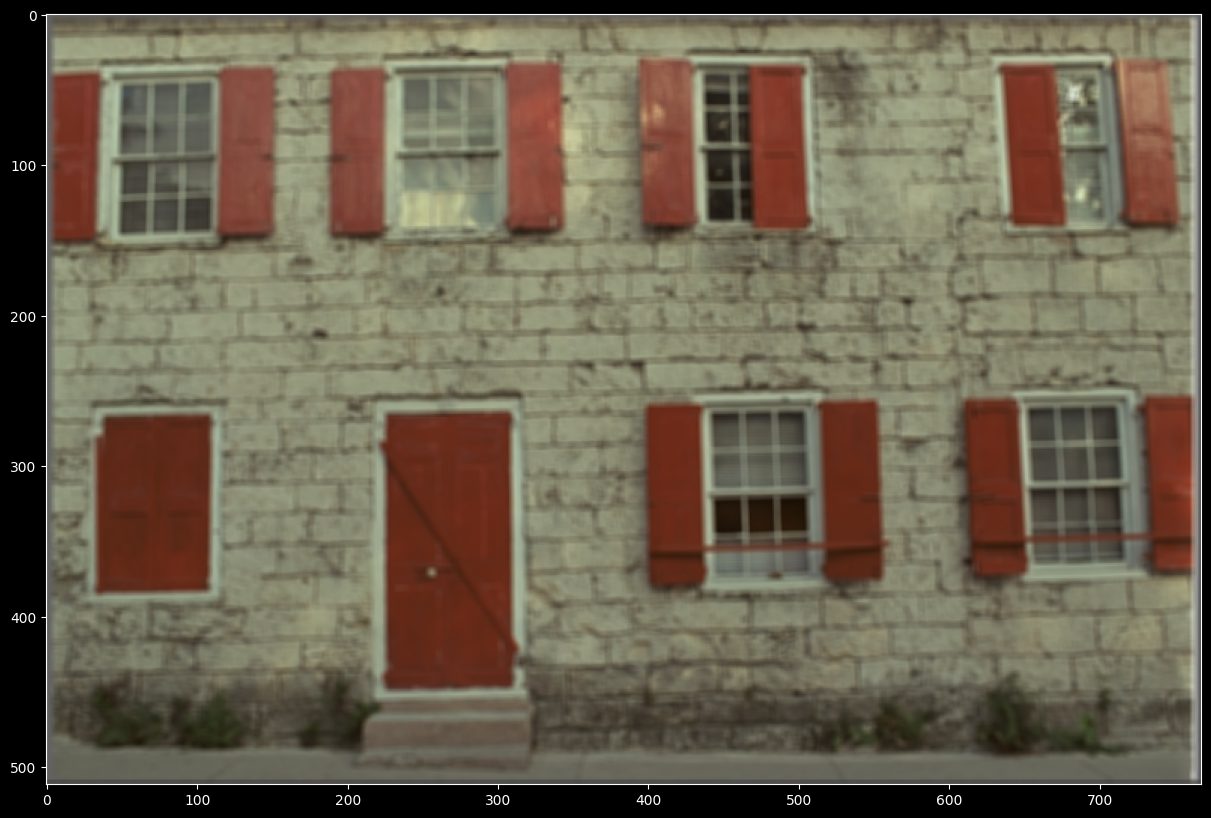

In [3]:
# Create a blurred (unsharp) version of the original image (you can use Gaussian blurring)
unsharp = cv2.GaussianBlur(img, ksize=(5,5), sigmaX=5)
plt.imshow(unsharp)

original shape: (512, 768, 3), d-type: uint8
blurred shape: (512, 768, 3), d-type: uint8


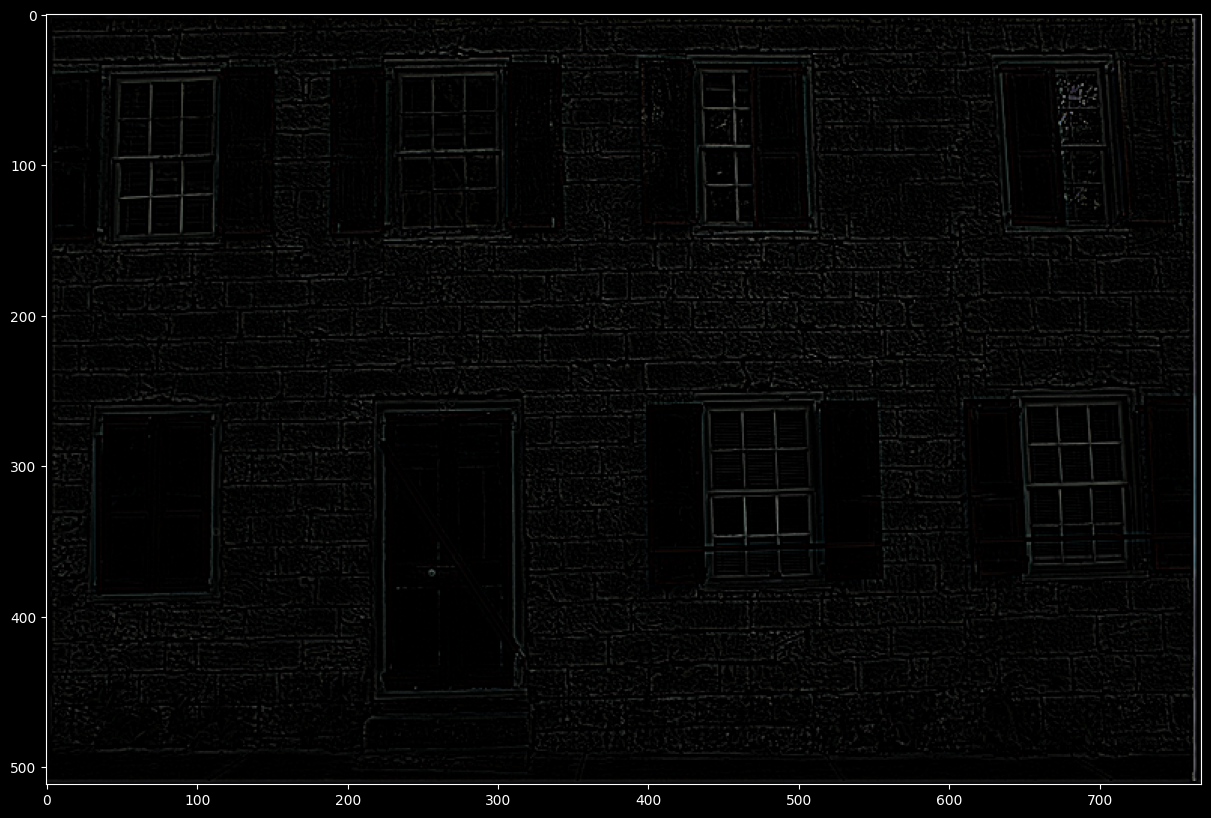

In [8]:
# Create the difference image (original − unsharp)
# Note: Remember that you are working with uint8 data types. Any addition or substractions
# might result in overflow or underflow, respectively. You can prevent this by casting the images to float.
print(f'original shape: {img.shape}, d-type: {img.dtype}')
print(f'blurred shape: {unsharp.shape}, d-type: {unsharp.dtype}')

diff = img.astype(np.float64) - unsharp.astype(np.float64)
diff = np.clip(diff, 0, 255).astype(np.uint8)

plt.imshow(diff)

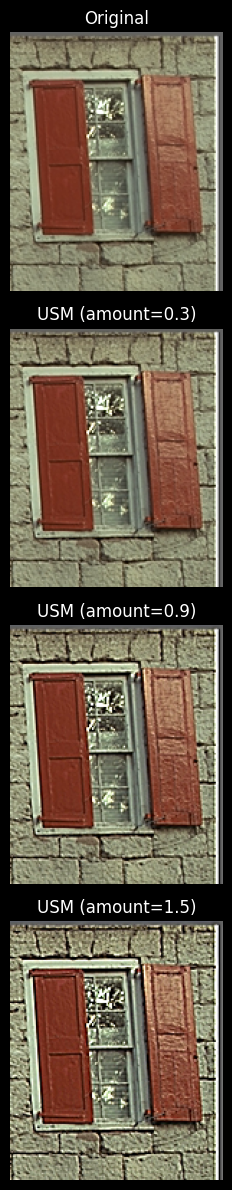

In [40]:
# Apply USM to get the resulting image using `sharpened = original + (original − unsharp) × amount`
# Note: Again, take care of underflows/overflows if necessary.

from functools import partial
import numpy as np

def usm(orig_img: np.ndarray, unsharp_img: np.ndarray, amount: float = 0.9) -> np.ndarray:
    orig_f = orig_img.astype(np.float64)
    unsharp_f = unsharp_img.astype(np.float64)
    sharpened = orig_f + (orig_f - unsharp_f) * amount
    return np.clip(sharpened, 0, 255).astype(np.uint8)

# Create “specialized” versions that only change the factor (amount)
usm_partial = partial(usm, img, unsharp)

# Apply USM with different amount values
usm_03 = usm_partial(amount=0.3)
usm_09 = usm_partial(amount=0.9)
usm_15 = usm_partial(amount=1.5)

# # Wider figure (width, height)
fig, axes = plt.subplots(4, 1, figsize=(12, 12))  # increase 24 -> wider

axes[0].imshow(img[0:180, 620:]); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(usm_03[0:180, 620:]); axes[1].set_title('USM (amount=0.3)'); axes[1].axis('off')
axes[2].imshow(usm_09[0:180, 620:]); axes[2].set_title('USM (amount=0.9)'); axes[2].axis('off')
axes[3].imshow(usm_15[0:180, 620:]); axes[3].set_title('USM (amount=1.5)'); axes[3].axis('off')

plt.tight_layout()
plt.show()

### Questions
* Q: What is a good (reasonable) value for the `amount` parameter?
* A: Below 1.0 is generally good, as it enhances sharpness without introducing too much noise or artifacts. Values between 0.3 and 0.9 are often used for subtle to moderate sharpening effects.
* Q: What happens if it is too small?
* A: If the `amount` parameter is too small (e.g., below 0.1), the sharpening effect will be minimal or barely noticeable. The image may appear almost identical to the original, as the contribution of the unsharp mask is too low to make a significant difference.
* Q: What happens if it is too large?
* A: If the `amount` parameter is too large (e.g., above 1.5), the sharpening effect can become excessive, leading to unnatural-looking images. This can introduce artifacts such as halos around edges, increased noise, and an overall harsh appearance that detracts from the image quality.